# Import All Necessary Libraries

In [1]:
%pip install scikit-learn
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import numpy as np
import json
import os

from dataset_and_transforms import FaceFramesDataset, train_transforms, val_transforms

device = "cuda" if torch.cuda.is_available() else "cpu"
device


Note: you may need to restart the kernel to use updated packages.


'cpu'

# Dataset Paths

In [ ]:
# Root path
ROOT = r"H:\My Drive\MAJOR PROJECT"

train_meta = os.path.join(ROOT, "dataset/processed/metadata_train.csv")
val_meta   = os.path.join(ROOT, "dataset/processed/metadata_val.csv")
test_meta  = os.path.join(ROOT, "dataset/processed/metadata_test.csv")

# Output directories
MODEL_DIR   = os.path.join(ROOT, "models")
RESULTS_DIR = os.path.join(ROOT, "results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)


# Load Dataset

In [3]:
# Load training data
train_data = FaceFramesDataset(train_meta, transform=train_transforms)
val_data   = FaceFramesDataset(val_meta,   transform=val_transforms)
test_data  = FaceFramesDataset(test_meta,  transform=val_transforms)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

len(train_data), len(val_data), len(test_data)


(9760, 2093, 2096)

# Model Setup (ResNet50)

In [4]:
model = models.resnet50(weights="IMAGENET1K_V2")

# Replace last FC layer → 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)


# Train Loop

In [5]:
num_epochs = 5

history = {
    "epoch": [],
    "train_acc": [],
    "train_loss": [],
    "val_acc": [],
    "val_loss": []
}

for epoch in range(num_epochs):
    model.train()
    train_correct = 0
    train_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = train_correct / len(train_data)

    # Validation
    model.eval()
    val_correct = 0
    val_loss = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            val_correct += (outputs.argmax(1) == labels).sum().item()

    val_acc = val_correct / len(val_data)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

    # Save history
    history["epoch"].append(epoch+1)
    history["train_acc"].append(train_acc)
    history["train_loss"].append(train_loss)
    history["val_acc"].append(val_acc)
    history["val_loss"].append(val_loss)


Epoch 1/5 | Train Acc: 0.9750 | Val Acc: 0.9986
Epoch 2/5 | Train Acc: 0.9975 | Val Acc: 0.9986
Epoch 3/5 | Train Acc: 0.9984 | Val Acc: 0.9990
Epoch 4/5 | Train Acc: 0.9991 | Val Acc: 0.9986
Epoch 5/5 | Train Acc: 0.9982 | Val Acc: 0.9967


# Save Training Logs

In [6]:
import pandas as pd

logs_df = pd.DataFrame(history)
logs_path = os.path.join(RESULTS_DIR, "training_logs.csv")
logs_df.to_csv(logs_path, index=False)

print("Training logs saved:", logs_path)


Training logs saved: H:\My Drive\MAJOR PROJECT\results\training_logs.csv


# Plot Accuracy & Loss

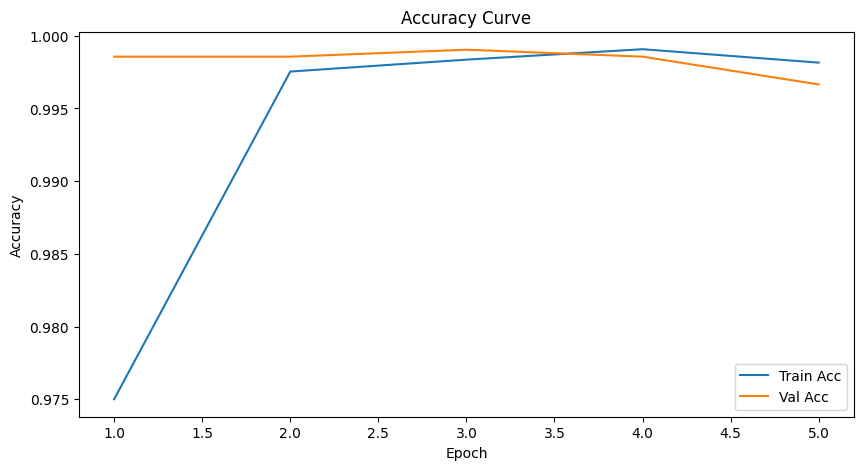

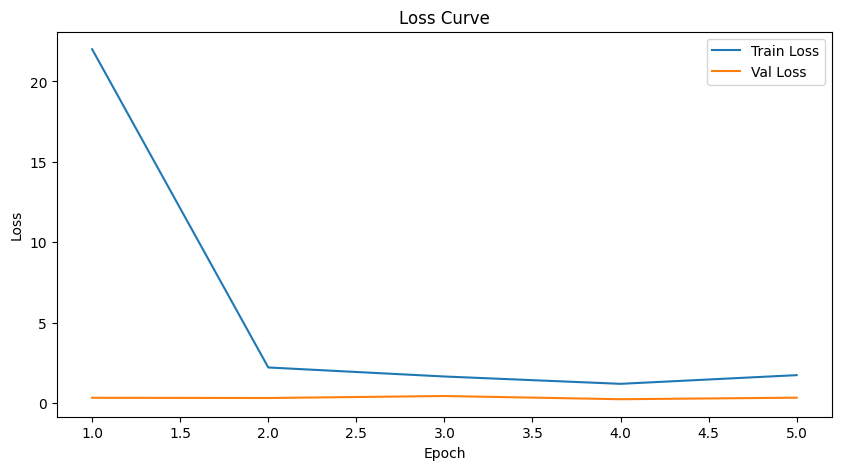

In [7]:
plt.figure(figsize=(10,5))
plt.plot(history["epoch"], history["train_acc"], label="Train Acc")
plt.plot(history["epoch"], history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig(os.path.join(RESULTS_DIR, "accuracy_curve.png"))
plt.show()

plt.figure(figsize=(10,5))
plt.plot(history["epoch"], history["train_loss"], label="Train Loss")
plt.plot(history["epoch"], history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig(os.path.join(RESULTS_DIR, "loss_curve.png"))
plt.show()


# Evaluation (Test Set)

In [8]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for imgs, labels in test_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1080
           1       1.00      1.00      1.00      1016

    accuracy                           1.00      2096
   macro avg       1.00      1.00      1.00      2096
weighted avg       1.00      1.00      1.00      2096



# Confusion Matrix

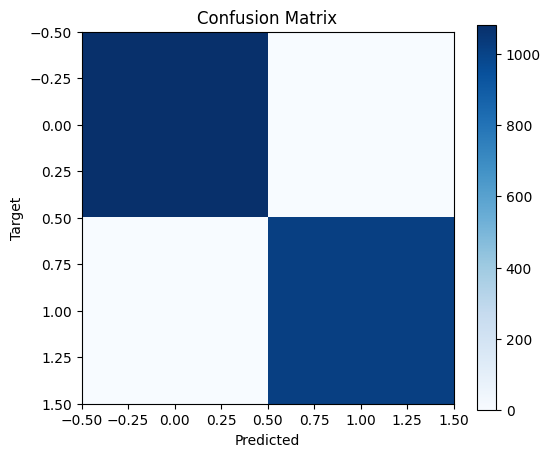

In [9]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Target")
plt.savefig(os.path.join(RESULTS_DIR, "confusion_matrix.png"))
plt.show()


# ROC Curve

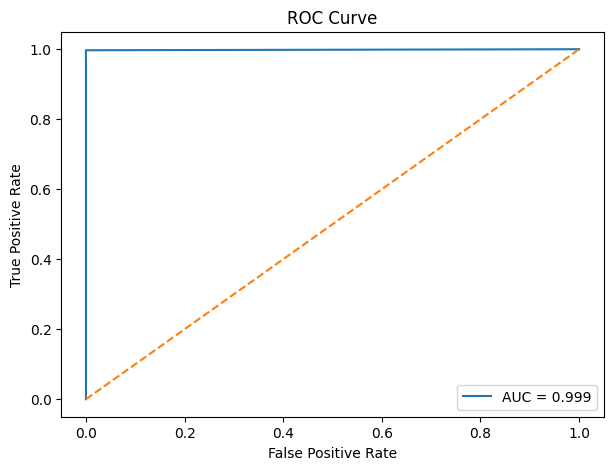

In [10]:
y_true_np = np.array(y_true)
y_pred_np = np.array(y_pred)

fpr, tpr, _ = roc_curve(y_true_np, y_pred_np)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig(os.path.join(RESULTS_DIR, "roc_curve.png"))
plt.show()
